Running on: cpu

Training for nu = 1.000e-02
Iter    100 | Loss 6.505e-02
Iter    200 | Loss 2.841e-02
Iter    300 | Loss 1.580e-02
Iter    400 | Loss 1.113e-02
Iter    500 | Loss 6.565e-03
Iter    600 | Loss 4.450e-03
Iter    700 | Loss 3.013e-03
Iter    800 | Loss 1.726e-03
Iter    900 | Loss 1.359e-03
Iter   1000 | Loss 1.072e-03
Iter   1100 | Loss 9.133e-04
Iter   1200 | Loss 7.540e-04
Iter   1300 | Loss 6.350e-04
Iter   1400 | Loss 5.270e-04
Iter   1500 | Loss 4.457e-04
Iter   1600 | Loss 3.617e-04
Iter   1700 | Loss 3.176e-04
Iter   1800 | Loss 2.655e-04
Iter   1900 | Loss 2.333e-04
Iter   2000 | Loss 2.012e-04
Iter   2100 | Loss 1.678e-04
Iter   2200 | Loss 1.424e-04
Iter   2300 | Loss 1.258e-04
Iter   2400 | Loss 1.138e-04
Iter   2500 | Loss 1.036e-04
Iter   2600 | Loss 9.483e-05
Iter   2700 | Loss 8.712e-05
Iter   2800 | Loss 8.100e-05
Iter   2900 | Loss 7.612e-05
Iter   3000 | Loss 7.214e-05
Iter   3100 | Loss 6.737e-05
Iter   3200 | Loss 6.094e-05
Iter   3300 | Loss 5.751e-0

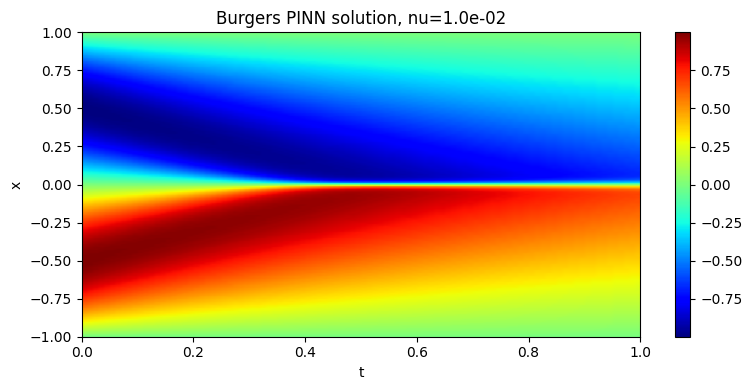


Training for nu = 1.000e-03
Iter    100 | Loss 7.492e-02
Iter    200 | Loss 4.809e-02
Iter    300 | Loss 4.117e-02
Iter    400 | Loss 3.894e-02
Iter    500 | Loss 3.541e-02
Iter    600 | Loss 3.381e-02
Iter    700 | Loss 3.247e-02
Iter    800 | Loss 3.114e-02
Iter    900 | Loss 2.738e-02
Iter   1000 | Loss 2.210e-02
Iter   1100 | Loss 1.867e-02
Iter   1200 | Loss 1.654e-02
Iter   1300 | Loss 1.511e-02
Iter   1400 | Loss 1.347e-02
Iter   1500 | Loss 1.217e-02
Iter   1600 | Loss 1.155e-02
Iter   1700 | Loss 1.096e-02
Iter   1800 | Loss 1.018e-02
Iter   1900 | Loss 9.759e-03
Iter   2000 | Loss 9.401e-03
Iter   2100 | Loss 8.836e-03
Iter   2200 | Loss 8.387e-03
Iter   2300 | Loss 8.050e-03
Iter   2400 | Loss 7.812e-03
Iter   2500 | Loss 7.638e-03
Iter   2600 | Loss 7.517e-03
Iter   2700 | Loss 7.359e-03
Iter   2800 | Loss 7.207e-03
Iter   2900 | Loss 6.817e-03
Iter   3000 | Loss 6.525e-03
Iter   3100 | Loss 6.289e-03
Iter   3200 | Loss 6.073e-03
Iter   3300 | Loss 5.915e-03
Iter   3400 | 

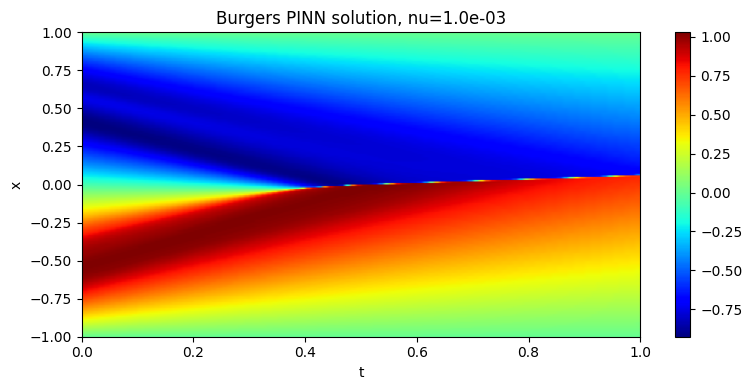

In [3]:
import torch
import torch.nn as nn
import numpy as np
from random import uniform
import matplotlib.pyplot as plt

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Running on: {device}")

torch.set_default_dtype(torch.float32)

class PhysicsInformedNN:
    def __init__(self, X_u, u, X_f, nu, print_every=10):
        self.nu = nu
        self.print_every = print_every

        # 2. Move data tensors to device immediately
        # Note: We set requires_grad=True directly on the device tensor
        self.x_u = torch.tensor(X_u[:, 0:1], dtype=torch.float32, device=device, requires_grad=True)
        self.t_u = torch.tensor(X_u[:, 1:2], dtype=torch.float32, device=device, requires_grad=True)

        self.x_f = torch.tensor(X_f[:, 0:1], dtype=torch.float32, device=device, requires_grad=True)
        self.t_f = torch.tensor(X_f[:, 1:2], dtype=torch.float32, device=device, requires_grad=True)

        self.u = torch.tensor(u, dtype=torch.float32, device=device)
        self.null = torch.zeros((self.x_f.shape[0], 1), device=device)

        # 3. Move model to device
        self.net = self.create_net().to(device)

        self.optimizer = torch.optim.LBFGS(
            self.net.parameters(),
            lr=1.0,
            max_iter=20000,
            max_eval=20000,
            history_size=50,
            tolerance_grad=1e-6,
            tolerance_change=1e-9,
            line_search_fn="strong_wolfe",
        )

        self.loss_fn = nn.MSELoss()
        self.iter = 0
        self.last_loss = None

    def create_net(self):
        return nn.Sequential(
            nn.Linear(2, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 20), nn.Tanh(),
            nn.Linear(20, 1)
        )

    def net_u(self, x, t):
        return self.net(torch.hstack((x, t)))

    def net_f(self, x, t):
        u = self.net_u(x, t)

        # torch.ones_like(u) automatically creates tensor on same device as u
        u_t = torch.autograd.grad(
            u, t, torch.ones_like(u), retain_graph=True, create_graph=True
        )[0]
        u_x = torch.autograd.grad(
            u, x, torch.ones_like(u), retain_graph=True, create_graph=True
        )[0]
        u_xx = torch.autograd.grad(
            u_x, x, torch.ones_like(u_x), retain_graph=True, create_graph=True
        )[0]

        return u_t + u * u_x - self.nu * u_xx

    def closure(self):
        self.optimizer.zero_grad()

        u_pred = self.net_u(self.x_u, self.t_u)
        f_pred = self.net_f(self.x_f, self.t_f)

        loss_u = self.loss_fn(u_pred, self.u)
        loss_f = self.loss_fn(f_pred, self.null)
        loss = loss_u + loss_f

        loss.backward()

        self.iter += 1
        self.last_loss = loss.item()

        if self.iter % self.print_every == 0:
            print(f"Iter {self.iter:6d} | Loss {self.last_loss:.3e}")

        return loss

    def train(self):
        self.net.train()
        self.optimizer.step(self.closure)

    def plot(self, title=None):
        self.net.eval()

        # Grid generation (still convenient to do on CPU using numpy or torch cpu)
        x = torch.linspace(-1, 1, 200)
        t = torch.linspace(0, 1, 100)
        X, T = torch.meshgrid(x, t, indexing="ij")

        # 4. Move plotting grid to device for inference
        xcol = X.reshape(-1, 1).to(device).requires_grad_(True)
        tcol = T.reshape(-1, 1).to(device).requires_grad_(True)

        # 5. Move result back to CPU for numpy conversion
        u = self.net_u(xcol, tcol).detach().cpu().numpy()
        U = u.reshape(200, 100)

        plt.figure(figsize=(8, 4))
        plt.imshow(
            U,
            extent=[0, 1, -1, 1],
            origin="lower",
            aspect="auto",
            cmap="jet",
        )
        plt.colorbar()
        if title:
            plt.title(title)
        plt.xlabel("t")
        plt.ylabel("x")
        plt.tight_layout()
        plt.show()

# -------------------------
# Data generation
# -------------------------
def make_data(N_u=100, N_f=10000, seed=0):
    np.random.seed(seed)

    x_upper = np.ones((N_u//4, 1))
    x_lower = -np.ones((N_u//4, 1))
    t_zero = np.zeros((N_u//2, 1))

    t_upper = np.random.rand(N_u//4, 1)
    t_lower = np.random.rand(N_u//4, 1)
    x_zero = -1 + 2 * np.random.rand(N_u//2, 1)

    X_u = np.vstack((
        np.hstack((x_upper, t_upper)),
        np.hstack((x_lower, t_lower)),
        np.hstack((x_zero,  t_zero)),
    ))

    idx = np.random.permutation(N_u)
    X_u = X_u[idx]

    u_upper = np.zeros((N_u//4, 1))
    u_lower = np.zeros((N_u//4, 1))
    u_zero = -np.sin(np.pi * x_zero)

    u = np.vstack((u_upper, u_lower, u_zero))[idx]

    X_f = np.random.rand(N_f, 2)
    X_f[:, 0] = -1 + 2 * X_f[:, 0]  # x ∈ [-1,1]

    X_f = np.vstack((X_f, X_u))

    return X_u.astype(np.float32), u.astype(np.float32), X_f.astype(np.float32)

# -------------------------
# Viscosity sweep
# -------------------------
if __name__ == "__main__":

    nus = [
        1e-2,
        1e-3,
    ]

    for nu in nus:
        print("\n" + "=" * 50)
        print(f"Training for nu = {nu:.3e}")
        print("=" * 50)

        X_u, u, X_f = make_data()

        pinn = PhysicsInformedNN(X_u, u, X_f, nu, print_every=100)
        pinn.train()

        pinn.plot(title=f"Burgers PINN solution, nu={nu:.1e}")